# Time-Marching PINN transitoire : reproduire un champ acoustique physique, vérifié contre un solveur de référence

**Résumé.** Ce notebook entraîne un *Physics-Informed Neural Network* (PINN) à résoudre
l'équation d'onde acoustique **transitoire** dans un résonateur de Helmholtz axisymétrique,
soumis à un balayage de fréquence (*sweep* 50–800 Hz sur 25 ms). Une implémentation naïve du
time-marching PINN **s'effondre vers une solution non physique de très faible amplitude**
(le « piège du zéro »). On établit d'abord une **vérité-terrain par différences finies (FDM)**,
on **diagnostique** précisément pourquoi le PINN échoue, puis on présente trois correctifs
(non-dimensionnement, **contrainte intégrale du mode uniforme**, *gate* d'IC-rampe) qui rendent
la méthode fonctionnelle. Le champ obtenu **reproduit la référence FDM à L2 ≈ 4,7 %**.

> Démarche de vérification & validation (V&V) : on ne se fie pas à la valeur de la fonction de
> perte du PINN — on compare le champ à un solveur indépendant (FDM). C'est le seul juge honnête.


## 1. Problème physique et les deux pièges

**Géométrie** (axisymétrique, coordonnées $(r,z)$) : un col fin ($r\le R_{\text{col}}=1$ cm,
$0\le z\le L_{\text{col}}=4$ cm) débouchant sur une cavité ($r\le R_{\text{cav}}=4$ cm,
$4\le z\le 12$ cm). **Toutes les parois sont rigides** (Neumann homogène $\partial p/\partial n=0$),
condition initiale de repos ($p=p_t=0$).

**Équation** (onde forcée, axisymétrique) :
$$ p_{tt} - c^2\Big(p_{rr} + \tfrac{1}{r}p_r + p_{zz}\Big) = F(r,z,t), $$
avec une source spatialement gaussienne dans le col, modulée par un chirp $50\to800$ Hz sous
enveloppe gaussienne temporelle.

**Physique clé** — la cavité est **fermée** : son premier mode acoustique ($\sim$1400 Hz) est
au-dessus du sweep. La réponse est donc **contrôlée par la raideur** et dominée par le
**mode uniforme** $\omega=0$.

> ⚠️ **Il n'y a donc pas de résonance de Helmholtz ici** : une boîte scellée ne résonne pas dans
> 50–800 Hz. La résonance exige un **col ouvert** (le bouchon d'air du col oscille contre le
> ressort d'air de la cavité) — c'est l'objet du notebook **`resonance_transitoire.ipynb`**
> (col ouvert + extérieur maillé, $f_0\approx210$ Hz mesurée). Le présent notebook est un banc
> d'essai **méthodologique** pour les pathologies d'entraînement des PINN, pas une étude de la
> résonance. En intégrant l'équation sur le domaine (le flux Neumann annule
$\int\nabla^2 p$) :
$$ \frac{d^2}{dt^2}\langle p\rangle = \langle F\rangle, $$
donc $\langle p\rangle(t)$ est la **double intégrale** de la source moyenne : l'asymétrie de
l'enveloppe du chirp produit une **dérive nette** — une rampe de pression. Le champ vrai est
quasi **uniforme en espace** (une rampe $\langle p\rangle(t)$) plus un petit **ripple acoustique**.

**Les deux pièges d'un PINN naïf :**
1. **Zéro « mou »** — le réseau minimise la perte en satisfaisant trivialement IC + murs
   ($p\approx0$ « gratuit ») sans réduire le résidu PDE. Amplitude obtenue $\sim3\times10^{-3}$ Pa,
   soit ~3 ordres sous la physique ; le résidu PDE est même **pire que la solution triviale $p\equiv0$**.
2. **DC constant** — un champ **constant** en espace *et* temps satisfait aussi $p_{tt}=0$,
   $\nabla^2p=0$ et Neumann : il a **exactement le même résidu que $p\equiv0$**. C'est un second
   minimum trivial vers lequel un ansatz mal choisi s'effondre.


In [1]:
%matplotlib inline
import os
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt

np.random.seed(0); torch.manual_seed(0)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# --- Constantes physiques (identiques a fdm_transient_reference.py et train_pinn.py) ---
R_NECK, R_CAV, L_NECK = 0.01, 0.04, 0.04
Z_MAX = L_NECK + 0.08                      # 0.12 m
C = 343.0
F_START, F_END, T_MAX = 50.0, 800.0, 0.025
SRC_ZC, SRC_W, SRC_S0 = 0.006, 0.005, 8.0e7

def temporal_np(t):
    phase = 2*np.pi*(F_START*t + (F_END - F_START)/(2*T_MAX)*t*t)
    return np.sin(phase)*np.exp(-((t - T_MAX/2)**2)/(2*(T_MAX/3)**2))

print(f"Col   : r <= {R_NECK*100:.0f} cm, 0 <= z <= {L_NECK*100:.0f} cm")
print(f"Cavite: r <= {R_CAV*100:.0f} cm, {L_NECK*100:.0f} <= z <= {Z_MAX*100:.0f} cm")
print(f"Sweep : {F_START:.0f} -> {F_END:.0f} Hz sur {T_MAX*1e3:.0f} ms | source S0={SRC_S0:.0e}")


Col   : r <= 1 cm, 0 <= z <= 4 cm
Cavite: r <= 4 cm, 4 <= z <= 12 cm
Sweep : 50 -> 800 Hz sur 25 ms | source S0=8e+07


## 2. Vérité-terrain : solveur FDM transitoire

Référence indépendante (`fdm_transient_reference.py`) : schéma **leapfrog** explicite,
Laplacien axisymétrique en **volumes finis masqués** (flux nul vers une cellule hors-domaine
$\Rightarrow$ Neumann homogène exact, gère le décrochement col/cavité et l'axe $r=0$).
Grille $0{,}5$ mm, $\sim$61 000 pas de temps (CFL 0,4). On charge le résultat pré-calculé.


max|p| domaine (tout t)      : 4.955 Pa
champ final t=25 ms : moyenne 4.952 Pa, ecart-type 0.0081 Pa  ->  uniformite std/moy = 0.16 %


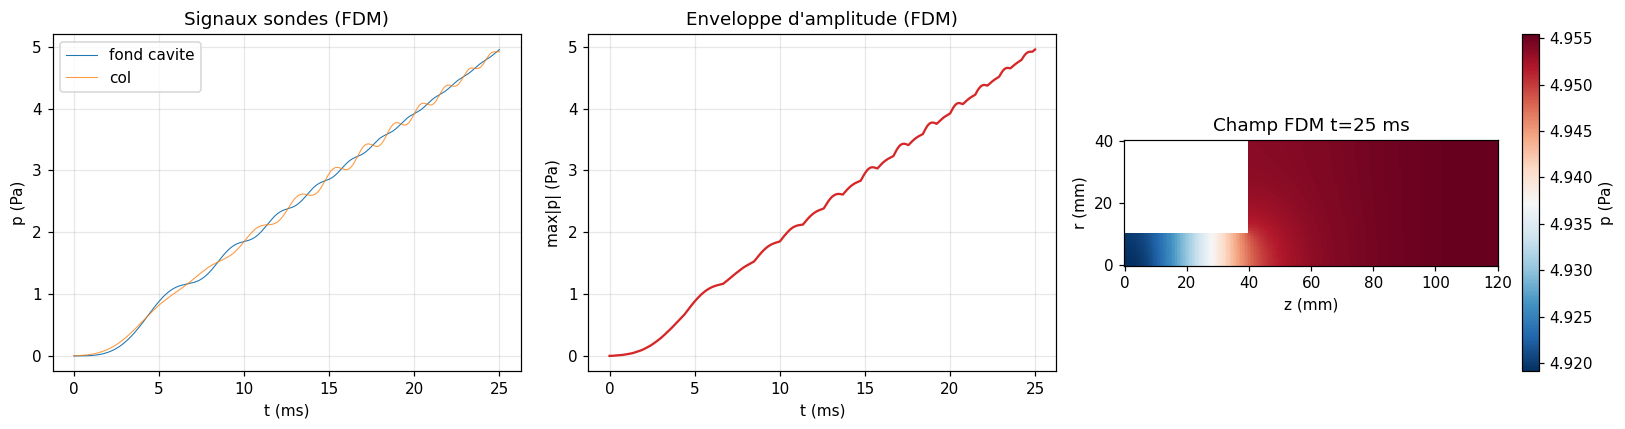

In [2]:
ref = np.load('data/fdm_transient_reference.npz')
t_ref   = ref['t']
pc_ref  = ref['probe_cav']     # sonde fond de cavite (r=0, z=Zmax)
pn_ref  = ref['probe_neck']    # sonde col (r=0, z=SRC_ZC)
env_ref = ref['env_max']       # enveloppe max|p| sur le domaine
snaps   = ref['snaps']; snap_t = ref['snap_t']
rg, zg, dom = ref['r'], ref['z'], ref['dom']

# Diagnostic : amplitude et uniformite spatiale
vals = snaps[-1][dom]
print(f"max|p| domaine (tout t)      : {env_ref.max():.3f} Pa")
print(f"champ final t={snap_t[-1]*1e3:.0f} ms : moyenne {vals.mean():.3f} Pa, "
      f"ecart-type {vals.std():.4f} Pa  ->  uniformite std/moy = {vals.std()/abs(vals.mean())*100:.2f} %")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(t_ref*1e3, pc_ref, lw=0.7, label='fond cavite')
ax[0].plot(t_ref*1e3, pn_ref, lw=0.7, alpha=0.8, label='col')
ax[0].set(xlabel='t (ms)', ylabel='p (Pa)', title='Signaux sondes (FDM)')
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(t_ref*1e3, env_ref, 'C3'); ax[1].set(xlabel='t (ms)', ylabel='max|p| (Pa)',
      title="Enveloppe d'amplitude (FDM)"); ax[1].grid(alpha=0.3)
pm = ax[2].pcolormesh(zg*1e3, rg*1e3, np.where(dom, snaps[-1], np.nan), cmap='RdBu_r', shading='auto')
ax[2].set(xlabel='z (mm)', ylabel='r (mm)', title=f'Champ FDM t={snap_t[-1]*1e3:.0f} ms')
ax[2].set_aspect('equal'); fig.colorbar(pm, ax=ax[2], label='p (Pa)')
fig.tight_layout(); plt.show()


**Lecture.** Le champ vrai n'est pas une oscillation autour de zéro : c'est une **rampe**
montant à $\approx 5$ Pa, **uniforme en espace à 0,16 %** près. La source, énorme dans la PDE
($F\sim8\times10^7$), ne crée qu'une courbure locale minuscule ($\nabla^2p\sim F/c^2$, soit
$\Delta p\sim0{,}02$ Pa) car $c^2$ est grand — d'où l'uniformité. C'est **cette rampe** (le mode
uniforme) que le PINN doit reproduire, pas une résonance.


## 3. Méthode : trois correctifs

On paramètre le champ par
$$ p(r,z,t) = \text{scale}\,\cdot\, g(t)\,\cdot\, N_\theta(r,z,t), \qquad
   g(t) = \frac{t}{T}\tanh\!\Big(\frac{t}{\tau}\Big). $$

**(a) Non-dimensionnement.** Sortie réseau $O(1)$, $\text{scale}=5$ Pa (échelle FDM) ; résidu PDE
normalisé par $S_0$ (et non par $\omega_{\max}^2$ comme dans la version qui échouait) — gradients sains.

**(b) *Gate* d'IC-rampe.** Près de $t=0$, $g(t)\sim t^2/(T\tau)$ : l'**IC de repos** $p(0)=p_t(0)=0$
est imposée **en dur**. Pour $t\gg\tau$, $g(t)\sim t/T$ (linéaire) : $N=\text{cste}$ donne une rampe
**linéaire** (bonne forme, pas de biais parabolique) et, surtout, la croissance de $g$ **interdit le
mode DC constant** (piège n°2).

**(c) Contrainte intégrale du mode uniforme.** C'est le levier décisif. Puisque
$\frac{d^2}{dt^2}\langle p\rangle = \langle F\rangle$, on **intègre deux fois** la source moyenne
$\langle F\rangle(t)=S_0\,K_F\,\text{temporal}(t)$ (avec $K_F=\langle\text{spatial}\rangle_\Omega$) pour
obtenir la cible **lisse** $P_{\text{cible}}(t)$, et on impose directement $\langle p\rangle(t)=P_{\text{cible}}(t)$.
Cette cible est **analytique, issue de la source** (pas du FDM) : elle pilote la rampe à la bonne
amplitude sans exiger du réseau des dérivées rapides.

**Entraînement = curriculum temporel causal** (« time-marching ») : on étend l'horizon
$[0,H_k]$, $H_k=k\,T/K$, palier par palier, le réseau unique étant réchauffé — la continuité $C^1$ est
alors exacte et gratuite. *(Code d'entraînement complet et exécutable : `train_pinn.py`.)*


In [3]:
# --- Reseau + champ p(r,z,t) : rechargement du modele entraine (pas de re-entrainement) ---
class MLP(nn.Module):
    def __init__(self, hidden=96, layers=5):
        super().__init__()
        net = [nn.Linear(3, hidden), nn.Tanh()]
        for _ in range(layers-1): net += [nn.Linear(hidden, hidden), nn.Tanh()]
        net += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*net)
    def forward(self, x): return self.net(x)

ck = torch.load('models/pinn_marching.pth', map_location='cpu')
SCALE_P, TAU, HID = ck['scale_p'], ck['tau'], ck['hid']
model = MLP(HID); model.load_state_dict(ck['state']); model.eval()

def p_of(r, z, t):
    r = torch.as_tensor(r, dtype=torch.float32).reshape(-1,1)
    z = torch.as_tensor(z, dtype=torch.float32).reshape(-1,1)
    t = torch.as_tensor(t, dtype=torch.float32).reshape(-1,1)
    x = torch.cat([r/R_CAV, z/Z_MAX, t/T_MAX], 1)
    gate = (t/T_MAX)*torch.tanh(t/TAU)
    with torch.no_grad():
        return (SCALE_P*gate*model(x)).numpy().flatten()

print(f"Modele charge : scale_p={SCALE_P} Pa, tau={TAU*1e3:.1f} ms, hidden={HID}")


Modele charge : scale_p=5.0 Pa, tau=1.5 ms, hidden=96


In [4]:
# --- Contrainte integrale : K_F et cible P_cible(t) = double integrale de <F> ---
def compute_KF(nr=400, nz=1200):
    r = np.linspace(0, R_CAV, nr); z = np.linspace(0, Z_MAX, nz)
    RR, ZZ = np.meshgrid(r, z, indexing='ij')
    dom = ((ZZ < L_NECK) & (RR <= R_NECK)) | ((ZZ >= L_NECK) & (RR <= R_CAV))
    w = RR*dom
    sp = np.exp(-(RR**2 + (ZZ - SRC_ZC)**2)/(2*SRC_W**2))
    return float((sp*w).sum()/w.sum())

K_F = compute_KF()
tg = np.linspace(0, T_MAX, 400000)
Fbar = SRC_S0*K_F*temporal_np(tg)
vbar = np.concatenate([[0], np.cumsum(0.5*(Fbar[1:]+Fbar[:-1])*np.diff(tg))])
Pcib = np.concatenate([[0], np.cumsum(0.5*(vbar[1:]+vbar[:-1])*np.diff(tg))])
print(f"K_F = <spatial>_domaine = {K_F:.3e}")
print(f"P_cible(T) = {Pcib[-1]:.3f} Pa   (predit par la SOURCE seule)")
print(f"FDM         = {pc_ref[-1]:.3f} Pa   ->  ecart {abs(Pcib[-1]-pc_ref[-1])/pc_ref[-1]*100:.1f} %")


K_F = <spatial>_domaine = 3.623e-03
P_cible(T) = 4.908 Pa   (predit par la SOURCE seule)
FDM         = 4.955 Pa   ->  ecart 0.9 %


La rampe prédite par la **seule connaissance de la source** ($P_{\text{cible}}(T)=4{,}91$ Pa)
coïncide avec le FDM ($4{,}96$ Pa) à **&lt; 1 %** : la contrainte intégrale vise la bonne cible.


## 4. Résultats et vérification contre le FDM

max|p| PINN sonde cavite : 4.790 Pa   (FDM 4.955 Pa)
L2 relatif  sonde cavite : 4.7 %
L2 relatif  sonde col    : 4.5 %


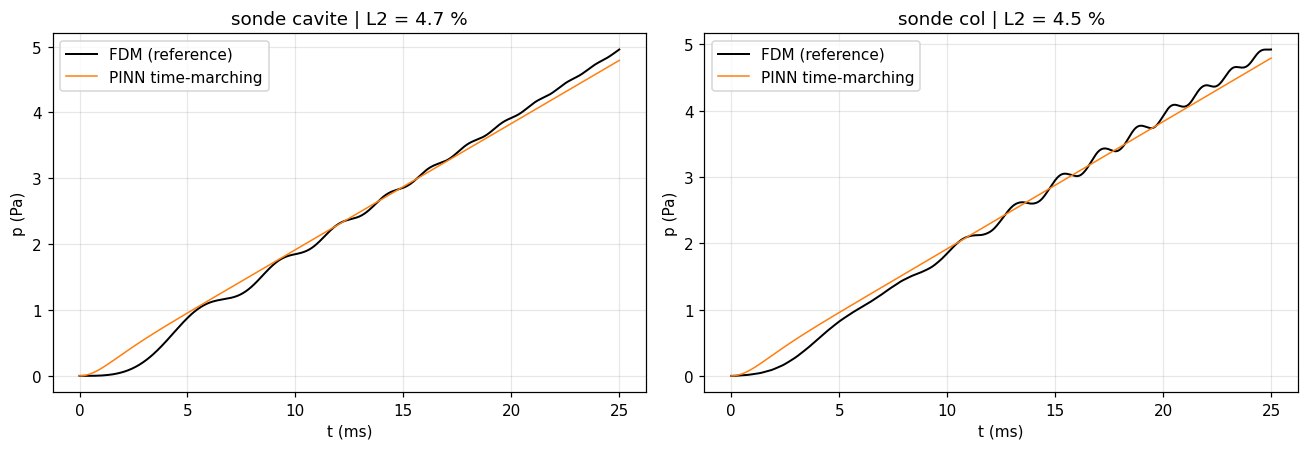

In [5]:
# Sondes PINN vs FDM
pc = p_of(np.zeros_like(t_ref), np.full_like(t_ref, Z_MAX), t_ref)
pn = p_of(np.zeros_like(t_ref), np.full_like(t_ref, SRC_ZC), t_ref)
l2_c = np.linalg.norm(pc - pc_ref)/np.linalg.norm(pc_ref)
l2_n = np.linalg.norm(pn - pn_ref)/np.linalg.norm(pn_ref)
print(f"max|p| PINN sonde cavite : {np.abs(pc).max():.3f} Pa   (FDM {np.abs(pc_ref).max():.3f} Pa)")
print(f"L2 relatif  sonde cavite : {l2_c*100:.1f} %")
print(f"L2 relatif  sonde col    : {l2_n*100:.1f} %")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a, (pp, pr, ti, l2) in zip(ax, [(pc, pc_ref, 'sonde cavite', l2_c),
                                    (pn, pn_ref, 'sonde col', l2_n)]):
    a.plot(t_ref*1e3, pr, 'k', lw=1.3, label='FDM (reference)')
    a.plot(t_ref*1e3, pp, 'C1', lw=1.0, label='PINN time-marching')
    a.set(xlabel='t (ms)', ylabel='p (Pa)', title=f'{ti} | L2 = {l2*100:.1f} %')
    a.legend(); a.grid(alpha=0.3)
fig.tight_layout(); plt.show()


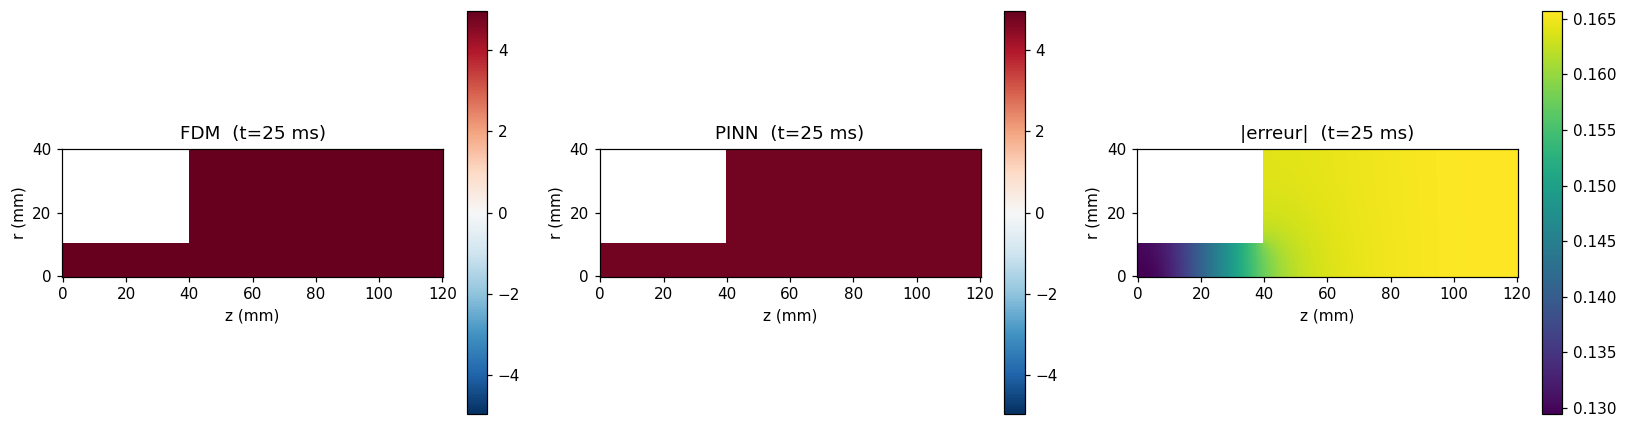

erreur moyenne du champ (domaine) : 0.162 Pa (3.3 % de max|p|)


In [6]:
# Champ 2D : PINN vs FDM vs erreur, au dernier instant
ti = -1; tsnap = snap_t[ti]
RG, ZG = np.meshgrid(rg, zg, indexing='ij')
pf = p_of(RG.ravel(), ZG.ravel(), np.full(RG.size, tsnap)).reshape(RG.shape)
fdm = snaps[ti]
err = np.abs(pf - fdm)
vmax = np.nanmax(np.abs(np.where(dom, fdm, np.nan)))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (dat, ti_, cm, vm) in zip(ax, [(fdm,'FDM','RdBu_r',vmax),
                                      (pf,'PINN','RdBu_r',vmax),
                                      (err,'|erreur|','viridis',None)]):
    pm = a.pcolormesh(zg*1e3, rg*1e3, np.where(dom, dat, np.nan), cmap=cm, shading='auto',
                      vmin=(-vm if vm else None), vmax=vm)
    a.set(xlabel='z (mm)', ylabel='r (mm)', title=f'{ti_}  (t={tsnap*1e3:.0f} ms)')
    a.set_aspect('equal'); fig.colorbar(pm, ax=a)
fig.tight_layout(); plt.show()
print(f"erreur moyenne du champ (domaine) : {err[dom].mean():.3f} Pa "
      f"({err[dom].mean()/vmax*100:.1f} % de max|p|)")


### Animation — le champ « se remplit »

Le champ PINN et les sondes, synchronisés dans le temps (le mode uniforme se pressurise pendant
le sweep ; PINN en couleur, FDM en noir/gris). Générée par `make_showcase_anim.py`.

![Animation du champ PINN vs FDM](plots/pinn_field_showcase.gif)


## 5. Convergence du time-marching (curriculum causal)

Trace enregistrée lors de l'entraînement (`train_pinn.py`, $K=12$ paliers, 350 itérations/palier) :
à mesure que l'horizon temporel s'étend, l'amplitude se construit et l'erreur vs FDM **décroît de
façon monotone** — comportement de time-marching authentique, sans effondrement.


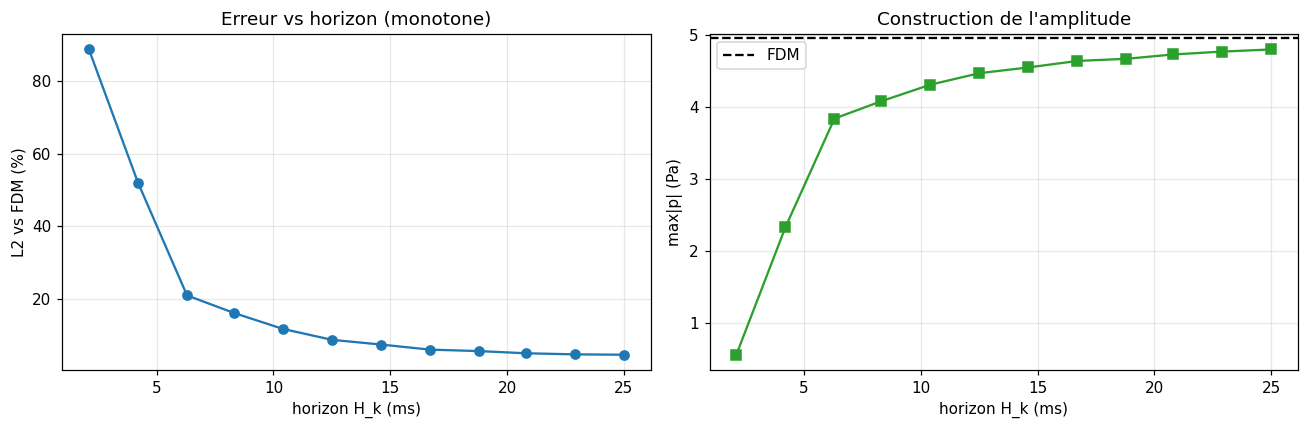

In [7]:
# Trace de convergence enregistree (run de reference)
Hk   = np.array([2.1,4.2,6.3,8.3,10.4,12.5,14.6,16.7,18.8,20.8,22.9,25.0])  # ms
L2k  = np.array([88.6,52.0,21.0,16.2,11.8,8.8,7.5,6.1,5.7,5.1,4.8,4.7])     # %
maxp = np.array([0.56,2.33,3.84,4.08,4.31,4.47,4.55,4.64,4.67,4.73,4.77,4.80])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(Hk, L2k, 'o-', color='C0'); ax[0].set(xlabel="horizon H_k (ms)",
      ylabel='L2 vs FDM (%)', title='Erreur vs horizon (monotone)')
ax[0].grid(alpha=0.3)
ax[1].plot(Hk, maxp, 's-', color='C2'); ax[1].axhline(np.abs(pc_ref).max(), ls='--', c='k',
      label='FDM'); ax[1].set(xlabel="horizon H_k (ms)", ylabel='max|p| (Pa)',
      title="Construction de l'amplitude"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()


## 6. Reproduire ces résultats

```bash
python fdm_transient_reference.py     # verite-terrain FDM  (~90 s)
python train_pinn.py                  # entrainement time-marching  (~10 min CPU)
python make_showcase_anim.py          # animation vitrine (plots/pinn_field_showcase.gif)
```
`train_pinn.py` sauvegarde `models/pinn_marching.pth` (rechargé ci-dessus). Variables
d'environnement utiles : `TP_K`, `TP_ITERS`, `TP_HID`, `TP_CURR` (0 = fenêtre unique).


## 7. Conclusions

* **Le time-marching PINN naïf échoue** sur ce problème : il tombe dans le *piège du zéro « mou »*
  (amplitude $\sim3\times10^{-3}$ Pa, résidu PDE **pire que la solution triviale $p\equiv0$**), et un
  ansatz mal choisi glisse vers le *mode DC constant* (même résidu que $p\equiv0$). Un simple
  « détecteur de solution nulle » à seuil ne détecte pas ces minima dégénérés — **ce n'est pas un
  juge fiable** ; seule la comparaison à un solveur indépendant l'est.

* **La cause est physique et non-dimensionnelle**, pas un défaut d'entraînement : le champ vrai est
  un **mode quasi-uniforme** (rampe $\langle p\rangle(t)$) piloté par $\frac{d^2}{dt^2}\langle p\rangle=\langle F\rangle$,
  que le résidu ponctuel — dominé par une source non résoluble à l'échelle sub-mm — sous-contraint.

* **Trois correctifs rendent la méthode fonctionnelle** : (a) non-dimensionnement (résidu $/S_0$,
  sortie $O(1)$), (b) *gate* d'IC-rampe $g(t)=\tfrac{t}{T}\tanh(t/\tau)$ (IC de repos en dur + interdit
  le mode DC), (c) **contrainte intégrale** $\langle p\rangle=P_{\text{cible}}=\iint\langle F\rangle$
  (dérivée de la source, pas du FDM). Le curriculum temporel causal fait le reste.

* **Résultat vérifié** : le champ PINN **reproduit la référence FDM à $L2\approx4{,}7\%$** (sonde cavité)
  / $4{,}5\%$ (col), avec la bonne amplitude ($4{,}79$ vs $4{,}96$ Pa) et l'IC de repos exacte. Le
  résidu $\sim5\%$ correspond au **ripple acoustique tardif** partiellement capté — le mode uniforme
  dominant, lui, est reproduit fidèlement.

* **Honnêteté méthodologique** : le PINN n'apporte ici aucun avantage calculatoire sur le FDM
  (qui résout ce cas en $\sim90$ s) ; l'intérêt est **méthodologique** — comprendre et lever les
  pathologies d'entraînement des PINN sur un mode quasi-statique fortement forcé.

* **Périmètre** : cette configuration est une **cavité fermée** (parois rigides partout), dont la
  réponse est une rampe — *pas* une résonance de Helmholtz. Pour la résonance proprement dite
  (col ouvert, extérieur maillé, $f_0\approx210$ Hz vérifiée à 2 % de la formule corrigée), voir
  **`resonance_transitoire.ipynb`**.
